# 05 — Model comparison, cross-validation and class imbalance

Why accuracy is misleading here, whether the ranking survives cross-validation, and whether resampling helps.

**Pipeline module:** `src/evaluate.py, src/cross_validation.py, src/imbalance.py`

*Every number and figure below was produced by the pipeline in `src/`. This
notebook reads those results; it does not re-implement them.*

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Image, display

TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

def table(name, **kw):
    """Read one of the pipeline's result tables."""
    return pd.read_csv(TABLES / name, **kw)

def figure(name):
    """Display one of the pipeline's figures."""
    return Image(filename=str(FIGURES / name))

print(f"project root: {ROOT}")

project root: C:\Users\babu\OneDrive\Desktop\ML Project


## Accuracy hides a model that detects almost nothing

Because 82.96% of traffic is benign, every model here clears 0.92 accuracy. The gap
between accuracy and F1 is what separates them.

In [2]:
allr = table("baseline_models_all.csv")
allr["accuracy_minus_f1"] = (allr["accuracy"] - allr["f1"]).round(4)
allr[["experiment", "model", "accuracy", "f1", "accuracy_minus_f1", "precision", "recall"]]

,experiment,model,accuracy,f1,accuracy_minus_f1,precision,recall
0,A (binary),XGBoost,0.998975,0.996997,0.0020,0.995976,0.998021
1,A (binary),Random Forest,0.998763,0.996372,0.0024,0.996262,0.996481
2,A (binary),Decision Tree,0.998275,0.994947,0.0033,0.993856,0.996041
3,A (binary),KNN,0.982577,0.948964,0.0336,0.947853,0.950077
4,A (binary),SVM (RBF),0.955717,0.853347,0.1024,0.980034,0.755663
5,A (binary),Logistic Regression,0.919596,0.712260,0.2073,0.913492,0.583682
6,B (multi),XGBoost,0.998813,0.958281,0.0405,0.977810,0.944294
7,B (multi),Random Forest,0.998725,0.958251,0.0405,0.987635,0.935692
8,B (multi),Decision Tree,0.998250,0.956328,0.0419,0.976064,0.941934
9,B (multi),KNN,0.982252,0.649362,0.3329,0.688557,0.625079


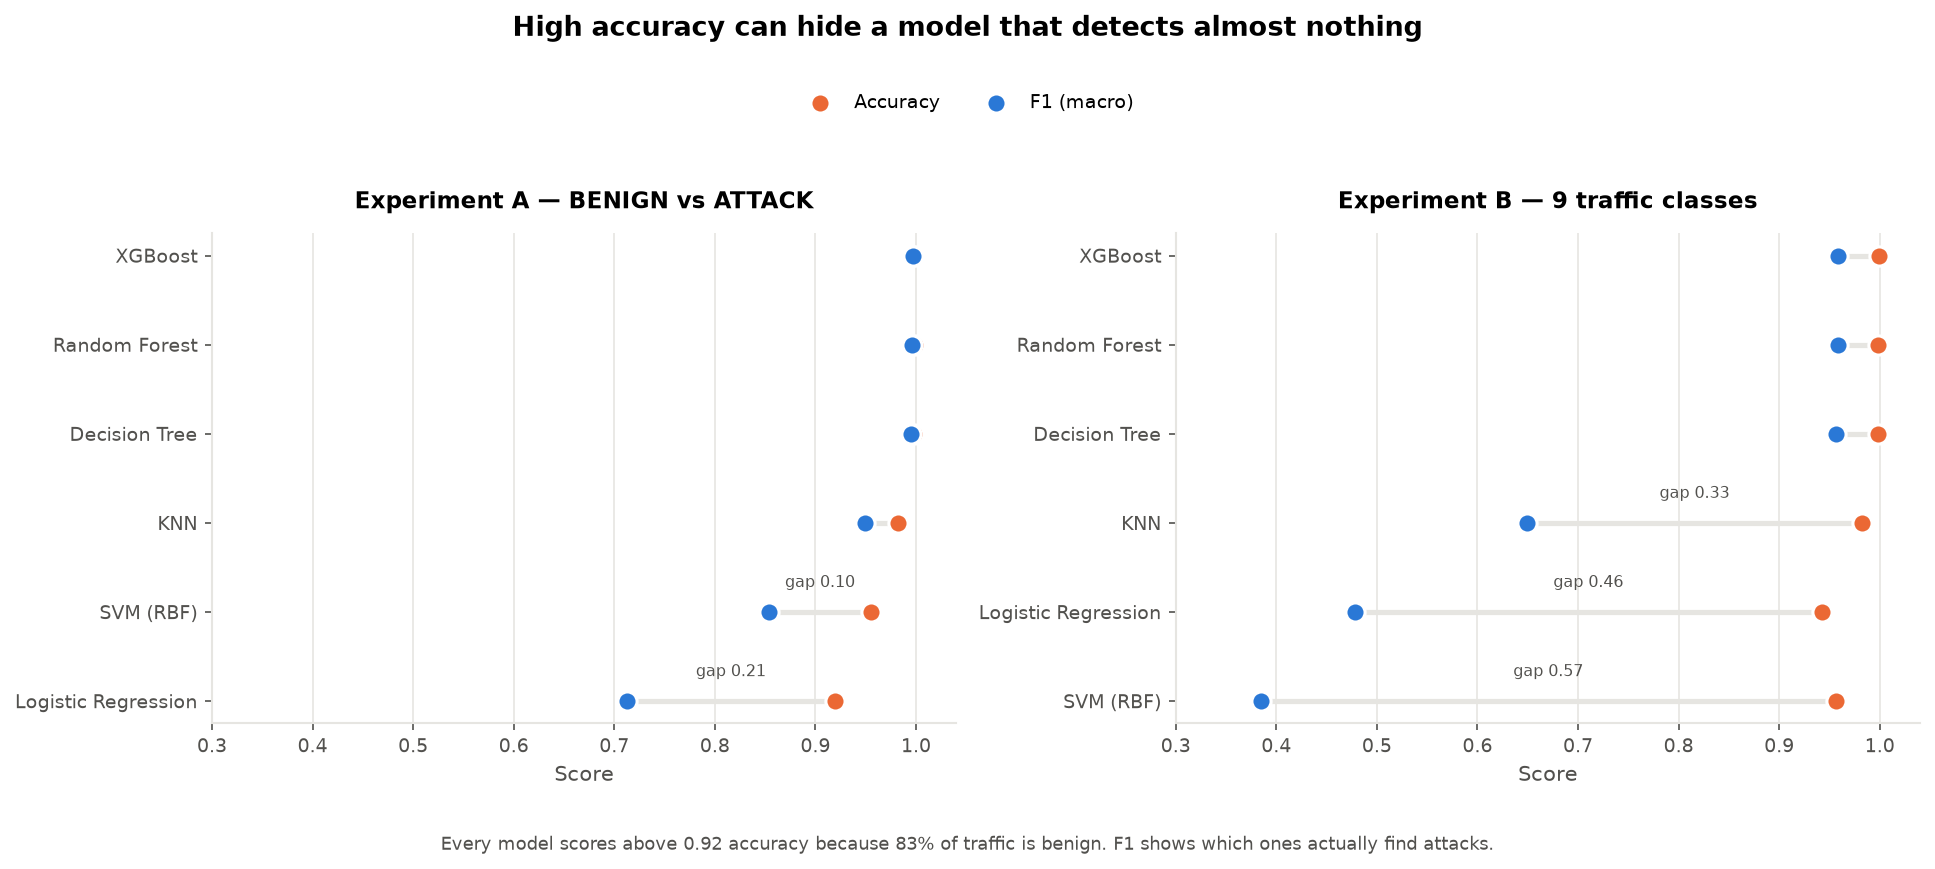

In [3]:
figure("08_accuracy_vs_f1.png")

**SVM on the multi-class task scores 0.9563 accuracy and 0.3844 F1** — a gap of 0.57.
It achieves that accuracy by predicting "BENIGN" for almost everything and being
rewarded by the class distribution. Deployed, attacks would walk straight past it.

XGBoost's gap is 0.04. High accuracy *and* high F1 — it is genuinely finding attacks.

## Cost is not symmetric

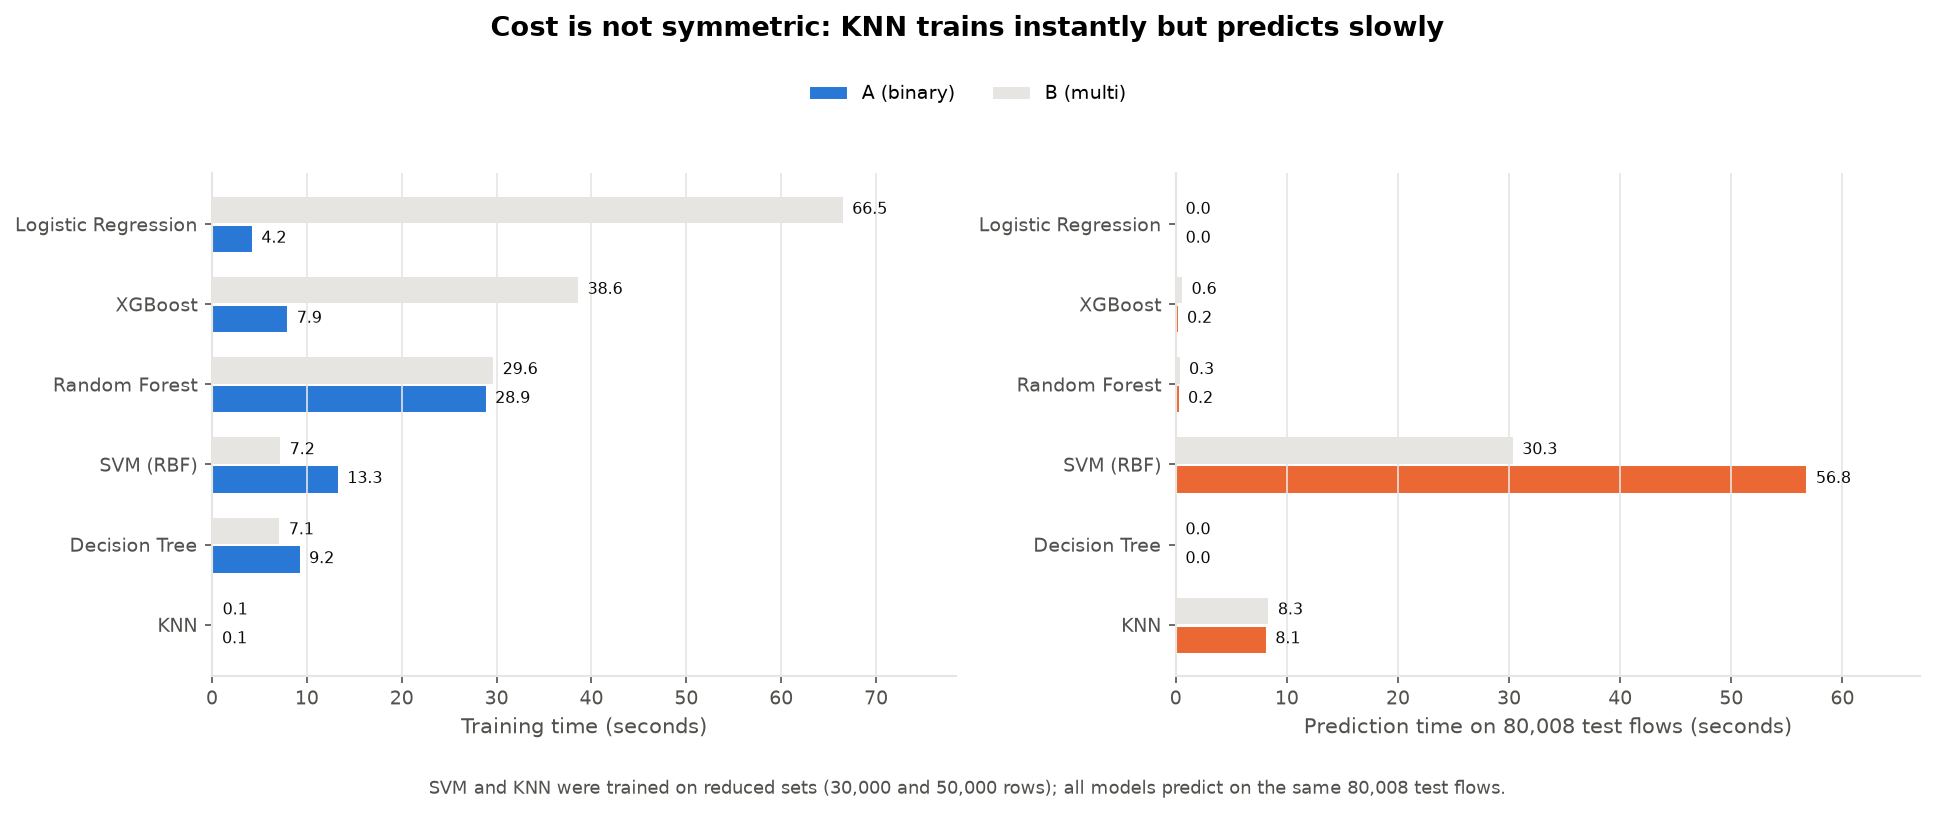

In [4]:
figure("09_model_cost.png")

KNN trains in 0.1 seconds and takes 8.1 seconds to predict. SVM takes 56.8 seconds to
predict. Trees and XGBoost predict in a fraction of a second. For a system watching
live traffic, **prediction** latency is the binding constraint — which disqualifies
KNN and SVM on architecture, not just accuracy.

## Cross-validation: does the ranking hold?

Every score above comes from a single split, which can be lucky or unlucky. Stratified
5-fold cross-validation refits each model five times.

In [5]:
cv_binary = table("cross_validation_binary.csv")
cv_multi = table("cross_validation_multi.csv")
cols = ["model", "f1_mean", "f1_std", "accuracy_mean", "total_seconds"]
display(cv_binary[cols].round(5))
display(cv_multi[cols].round(5))

,model,f1_mean,f1_std,accuracy_mean,total_seconds
0,XGBoost,0.99678,0.00059,0.99890,25.0
1,Random Forest,0.99588,0.00056,0.99860,100.8
2,Decision Tree,0.99497,0.00075,0.99828,57.8


,model,f1_mean,f1_std,accuracy_mean,total_seconds
0,Decision Tree,0.94868,0.01272,0.99797,62.5
1,Random Forest,0.93713,0.02821,0.99843,119.3
2,XGBoost,0.93360,0.02198,0.99865,145.4


**The binary ranking is stable** — a fold spread of 0.0016, and XGBoost leads while
training four times faster than Random Forest.

**The multi-class ranking is not.** It *reverses* under cross-validation: Decision
Tree now leads. Random Forest scored 0.9650 on one fold and 0.8830 on another, a
spread of 0.082 against model-to-model gaps of about 0.01. When the noise is eight
times the difference, the ranking is meaningless.

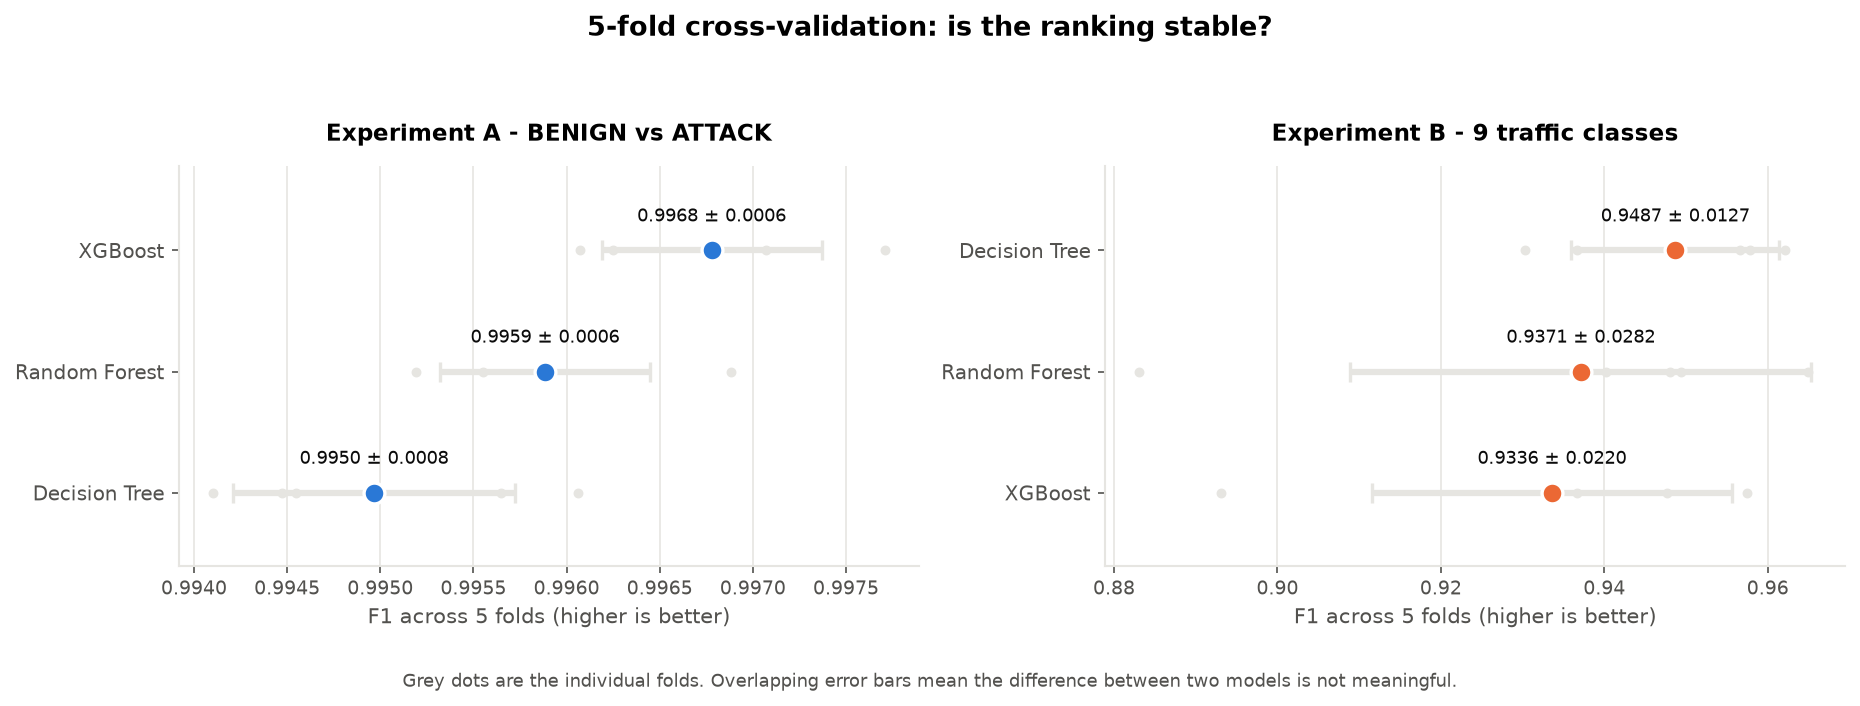

In [6]:
figure("10_cross_validation.png")

### Where the instability comes from

The obvious hypothesis — that Heartbleed's 9 rows destabilise the macro average — is
wrong. It does the opposite.

In [7]:
stability = table("per_class_stability.csv", index_col=0)
stability.round(4)

,fold1,fold2,fold3,fold4,fold5,mean,spread,train_rows
BENIGN,0.9989,0.9987,0.9989,0.9987,0.9989,0.9988,0.0002,265465
DoS,0.9956,0.9948,0.9950,0.9961,0.9951,0.9953,0.0013,24818
DDoS,0.9986,0.9982,0.9989,0.9988,0.9988,0.9987,0.0008,16397
PortScan,0.9912,0.9880,0.9903,0.9882,0.9916,0.9899,0.0036,11618
Brute Force,0.9936,0.9915,0.9979,0.9936,1.0000,0.9953,0.0085,1172
Web Attack,0.9636,0.9643,0.9730,0.8991,0.9643,0.9529,0.0739,274
Bot,0.8350,0.8000,0.7573,0.7551,0.7573,0.7809,0.0798,250
Infiltration,0.8333,0.9231,0.9091,0.8000,0.6667,0.8264,0.2564,29
Heartbleed,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,9


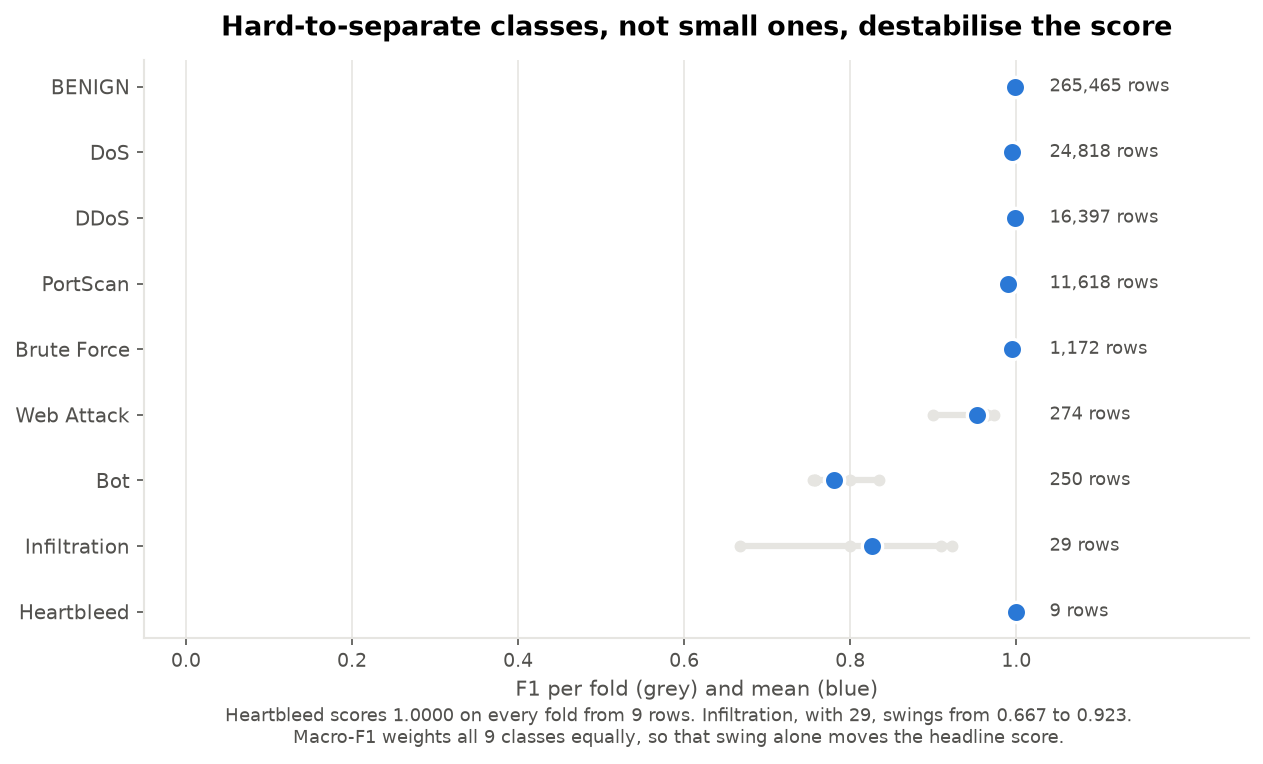

In [8]:
figure("11_per_class_stability.png")

**Heartbleed scores 1.0000 on every fold from 9 training rows**, because its exploit
has an unmistakable traffic signature. **Infiltration**, with three times as many
rows, swings between 0.667 and 0.923 — it is an attacker already inside the network
behaving like an ordinary user, so there is genuinely little to separate. **Bot**,
with 250 rows, is the weakest class at 0.78.

What destabilises the score is a class being *hard to separate*, not merely small.

## Class imbalance

Four strategies, compared by cross-validation on the **training split** — choosing a
strategy by its test score would let the test set influence the model. SMOTE runs
inside an `imblearn` Pipeline so it is applied per training fold, never before the
split.

In [9]:
imb_binary = table("imbalance_binary.csv")
imb_multi = table("imbalance_multi.csv")
cols = ["strategy", "f1_mean", "f1_std", "precision_mean", "recall_mean", "seconds"]
display(imb_binary[cols].round(5))
display(imb_multi[cols].round(5))

,strategy,f1_mean,f1_std,precision_mean,recall_mean,seconds
0,class weights,0.99555,0.00092,0.99485,0.99625,8.7
1,SMOTE,0.99506,0.00111,0.99438,0.99574,32.2
2,undersample (majority only),0.99478,0.00109,0.99534,0.99421,5.9
3,baseline,0.99475,0.00123,0.99627,0.99324,10.9
4,undersample (to minority),0.99396,0.00114,0.99079,0.99715,2.5


,strategy,f1_mean,f1_std,precision_mean,recall_mean,seconds
0,undersample (majority only),0.93693,0.00476,0.95903,0.92411,7.8
1,baseline,0.93253,0.01024,0.98349,0.90033,31.6
2,class weights,0.91803,0.01048,0.91432,0.95698,10.1
3,undersample (to minority),0.29125,0.02706,0.29420,0.80086,5.2


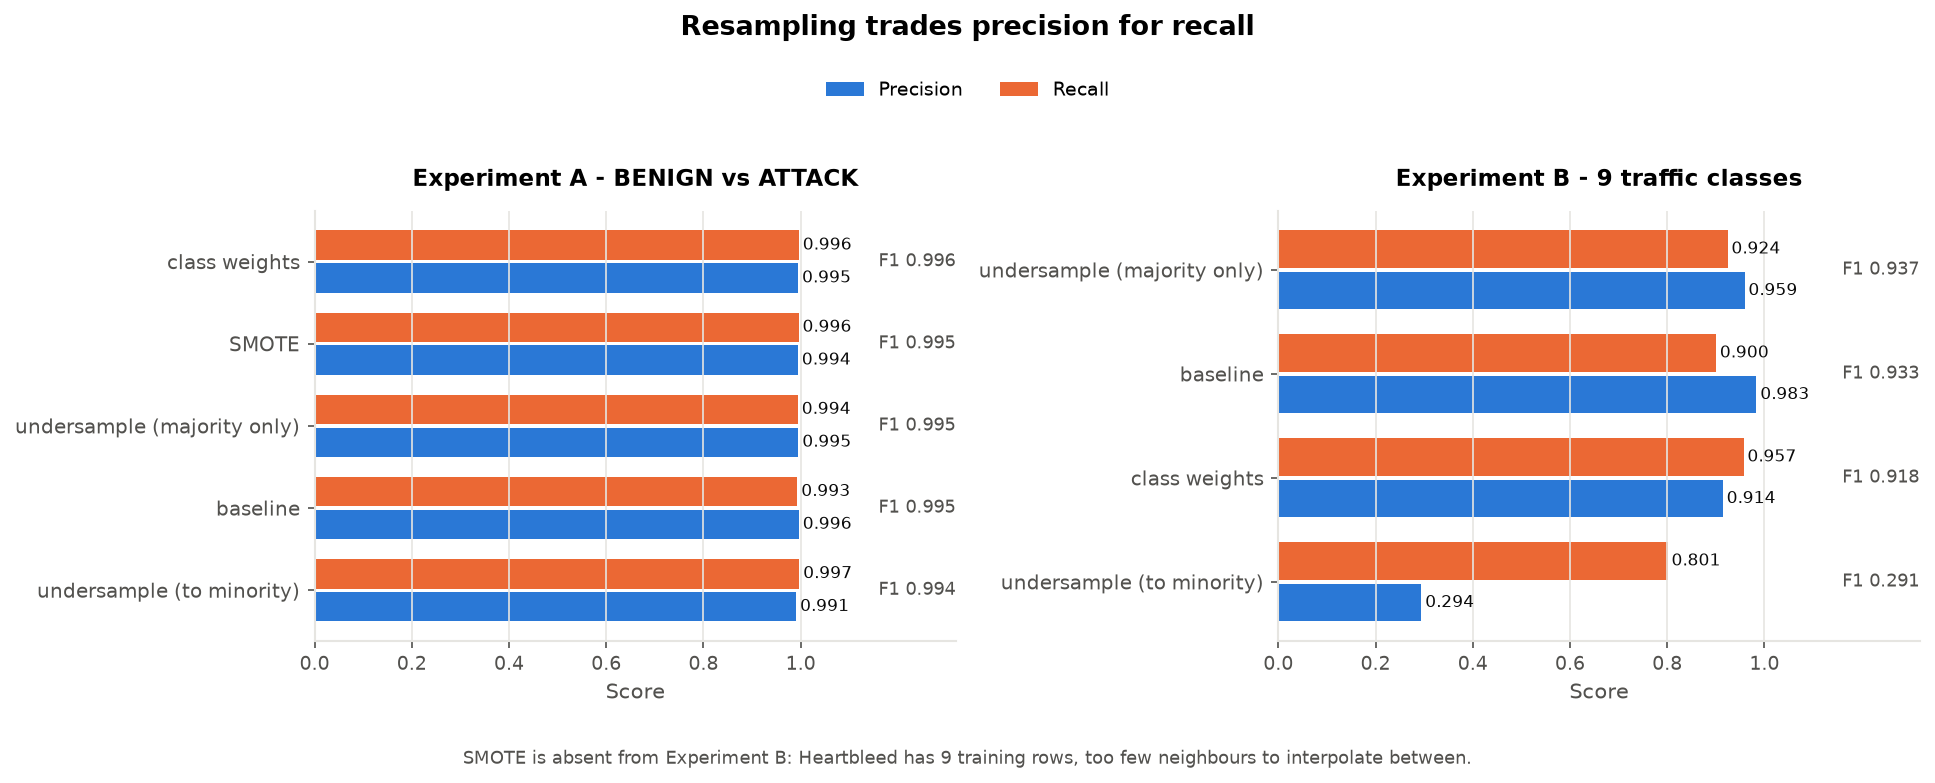

In [10]:
figure("12_class_imbalance.png")

### Two findings

**SMOTE cannot run on the multi-class task at all.** It interpolates between a rare
row and its k nearest same-class neighbours; Heartbleed has 9 training rows, which
drops to about 6 inside a fold — fewer than the algorithm needs. Forcing it with
`k_neighbors=1` would manufacture thousands of near-duplicates of two or three real
flows and teach the model those specific rows by heart.

**Configuration matters more than technique.** Undersampling appears twice on purpose.
`RandomUnderSampler`'s default reduces *every* class to the size of the smallest —
4 rows here — leaving about 36 training rows, and F1 collapses to 0.291. Capping only
the majority class instead gives **0.937**, the best multi-class result recorded and
the most stable of any strategy. Same technique, same data, one configuration line
between them.

On the binary task all five strategies sit within 0.0016 of each other, smaller than
the fold noise. The useful finding is the trade rather than the winner: baseline holds
the best precision and the worst recall, undersampling flips it exactly. **Catching
more attacks and raising more false alarms are the same dial.**